In [7]:
from netCDF4 import Dataset
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd

# Load the detailed shapefile for U.S. state boundaries
states = gpd.read_file('../data/Weather/SHP/cb_2018_us_state_500k.shp')

# Filter to include only the Contiguous United States (assuming 'STUSPS' is the state abbreviation column)
usa = states.iloc[[15, 9, 0,17, 18, 16, 35, 12, 5, 33, 2, 52, 23, 1, 26, 20, 3]]

if usa.crs is None:
  usa.set_crs("EPSG:4326", inplace=True)  # Set CRS to EPSG:4326 if none is defined
elif usa.crs != "EPSG:4326":
  usa = usa.to_crs("EPSG:4326")  # Convert CRS to EPSG:4326 if different

ds = Dataset('../data/Weather/CMIP/pr_Amon_GISS-E2-1-G_ssp460_r1i1p1f2_gn_20150116-20491216_v20200115.nc')
ds = Dataset( '../data/Weather/CMIP/SSP1/evspsbl_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc')


# Get the precipitation data
data = ds.variables['evspsbl'][:]  # Monthly data
lon = ds.variables['lon'][:]-360
lat = ds.variables['lat'][:]
print(data.shape)
# Create a GeoDataFrame from the grid points
mesh_lon, mesh_lat = np.meshgrid(lon, lat)
coords = np.vstack([mesh_lon.ravel(), mesh_lat.ravel()]).T
geo_df = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in coords], crs="EPSG:4326")


for i in range(0, 420, 1):
    geo_df[f'precipitation_{i}'] = data[i,:,:].ravel()


# Join the grid points with the US states based on location
point_in_usa = gpd.sjoin(geo_df, usa, how="inner", predicate='intersects')
# Calculate the mean precipitation for each precipitation_{i} column
mean_precip_by_state = {}
for i in range(7, 420, 12):
    col_name = f'precipitation_{i}'
    mean_precip_by_state[col_name] = point_in_usa.groupby('index_right')[col_name].mean()

# Convert the results to a DataFrame for better readability
mean_precip_by_state_df = pd.DataFrame(mean_precip_by_state)

print(mean_precip_by_state_df)

max_precip_by_state = {}
for i in range(7, 420, 12):
    col_name = f'precipitation_{i}'
    max_precip_by_state[col_name] = point_in_usa.groupby('index_right')[col_name].max()

# Convert the results to a DataFrame for better readability
max_precip_by_state_df = pd.DataFrame(max_precip_by_state)


min_precip_by_state = {}
for i in range(7, 420, 12):
    col_name = f'precipitation_{i}'
    min_precip_by_state[col_name] = point_in_usa.groupby('index_right')[col_name].min()

# Convert the results to a DataFrame for better readability
min_precip_by_state_df = pd.DataFrame(min_precip_by_state)

# Flatten each DataFrame into a 1D array
mean_values = mean_precip_by_state_df.values.flatten()
max_values = max_precip_by_state_df.values.flatten()
min_values = min_precip_by_state_df.values.flatten()

# Create a DataFrame for correlation calculation
precip_df = pd.DataFrame({
    'Mean': mean_values,
    'Max': max_values,
    'Min': min_values
})

# Compute the correlation matrix
overall_correlation = precip_df.corr()

# Display the correlation matrix
print(overall_correlation)

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Cons

(420, 26, 47)


/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

             precipitation_7  precipitation_19  precipitation_31  \
index_right                                                        
0                   0.000039          0.000037          0.000031   
1                   0.000041          0.000040          0.000042   
2                   0.000022          0.000024          0.000009   
3                   0.000041          0.000040          0.000041   
5                   0.000039          0.000038          0.000024   
9                   0.000042          0.000041          0.000039   
12                  0.000017          0.000017          0.000012   
15                  0.000016          0.000018          0.000009   
16                  0.000008          0.000010          0.000009   
17                  0.000042          0.000040          0.000041   
18                  0.000041          0.000040          0.000041   
20                  0.000033          0.000033          0.000013   
23                  0.000042          0.000038  

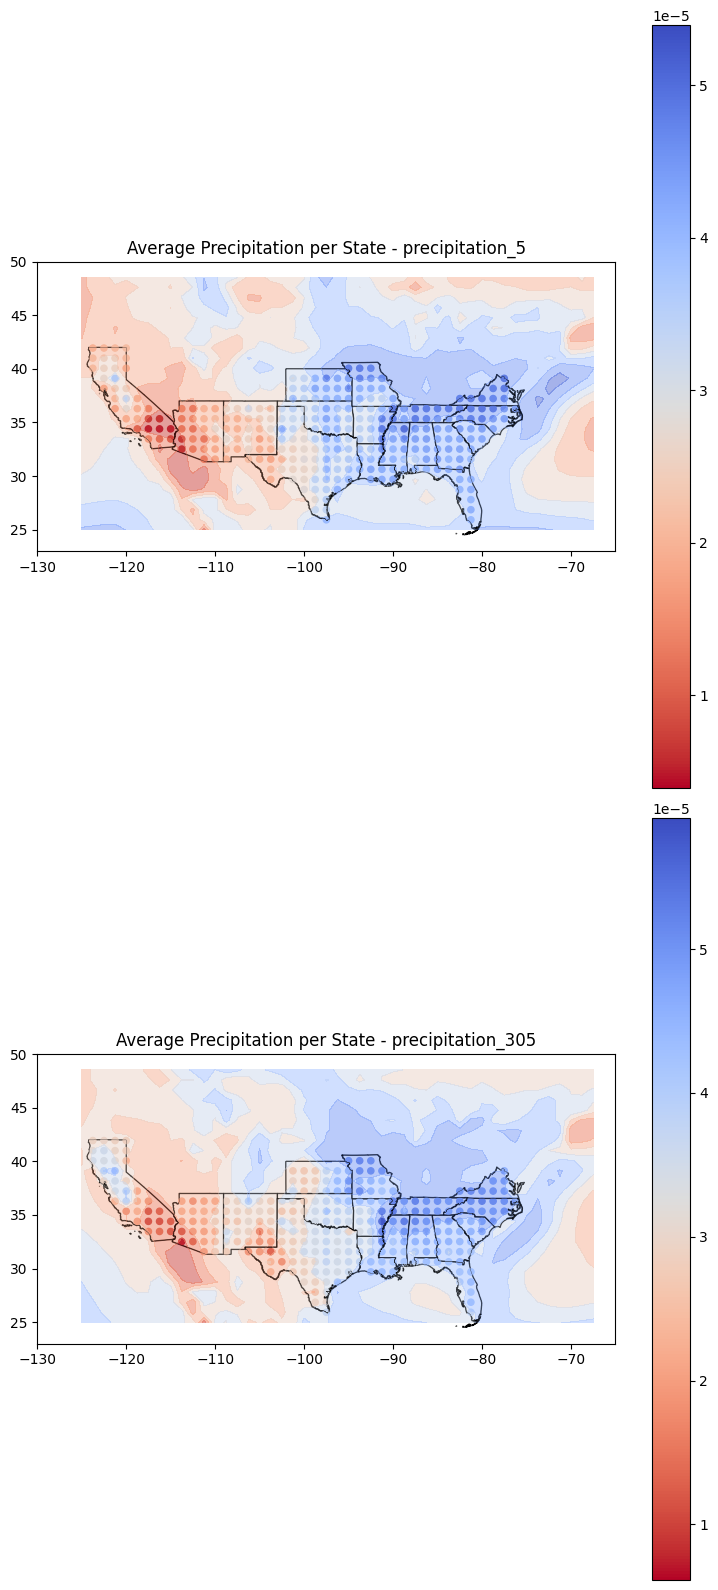

In [8]:
start, stop, step = 5, 420, 300
num_plots = len(range(start, stop, step))

fig, axes = plt.subplots(num_plots, 1, figsize=(7.8, num_plots * 8))

for idx, i in enumerate(range(start, stop, step)):
    ax = axes[idx] if num_plots > 1 else axes
    col_name = f'precipitation_{i}'

    ax.set_ylim(23, 50)
    ax.set_xlim(-130, -65)
    usa.boundary.plot(ax=ax, linewidth=0.2, color='k')
    usa.plot(ax=ax, color='white', edgecolor='black')
    point_in_usa.plot(ax=ax, column=col_name, cmap='coolwarm_r', legend=True, markersize=20)

    ax.contourf(lon, lat, data[i,:,:], cmap='coolwarm_r', alpha=0.5)

    ax.set_title(f'Average Precipitation per State - {col_name}')

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7.8, 6))
ax.set_ylim(23, 50)
ax.set_xlim(-130, -65)
usa.boundary.plot(ax=ax, linewidth=0.2, color='k')
usa.plot(ax=ax, color='white', edgecolor='black')
point_in_usa.plot(ax=ax, column='precipitation_125', cmap='coolwarm_r', legend=True, markersize=10)

plt.contourf(lon, lat, data[125,:,:], cmap='coolwarm_r', alpha=0.5)

plt.savefig('../outputs/weather/fig_map_tas.tiff')
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
# Load the detailed shapefile for U.S. state boundaries
states = gpd.read_file('../data/Weather/SHP/cb_2018_us_state_500k.shp')

# Filter to include only the Contiguous United States (assuming 'STUSPS' is the state abbreviation column)
usa = states.iloc[[15, 9, 0,17, 18, 16, 35, 12, 5, 33, 2, 52, 23, 1, 26, 20, 3]]


# Create a column with unique values for each state (for coloring purposes)
usa['color'] = range(len(usa))

# Define the colors
num_blues = 6
num_reds = 5
num_yellows = 3
num_browns = 3

# Generate colors for each group
blues = plt.cm.Greys(np.linspace(0.5, 0.8, num_blues))  # Vary alpha value for different shades of blue
reds = plt.cm.Purples(np.linspace(0.2, 0.6, num_reds))
yellows = plt.cm.Oranges(np.linspace(0.2, 0.6, num_yellows))
browns = plt.cm.Blues([0.3, 0.7, 0.9])

# Concatenate colors from each group
colors = np.concatenate((blues, reds, yellows, browns))

# Define the new order of rows
new_order = [13, 4, 8, 1, 5, 14, 16, 15, 7, 3, 12, 10, 6, 2, 11, 9, 0]

colors = colors[new_order]
print(colors.shape)

custom_cmap = ListedColormap(colors)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(7.2, 1.8))
usa.plot(column='color', ax=ax, legend=False, cmap=custom_cmap, edgecolor='black', linewidth=0.5)
plt.savefig('../outputs/weather/fig1_map.eps',format='eps')
plt.show()



In [ ]:
import geopandas as gpd
import numpy as np
from netCDF4 import Dataset
from shapely.geometry import Point
import pandas as pd

def load_and_process_data(shapefile_path, netcdf_file_path, var_name):
    # Load the detailed shapefile for U.S. state boundaries
    states = gpd.read_file(shapefile_path)

    # Filter to include only the Contiguous United States (assuming 'STUSPS' is the state abbreviation column)
    usa = states.iloc[[15, 9, 0,17, 18, 16, 35, 12, 5, 33, 2, 52, 23, 1, 26, 20, 3]]

    if usa.crs is None:
        usa.set_crs("EPSG:4326", inplace=True)  # Set CRS to EPSG:4326 if none is defined
    elif usa.crs != "EPSG:4326":
        usa = usa.to_crs("EPSG:4326")  # Convert CRS to EPSG:4326 if different


    # Load the NetCDF dataset
    ds = Dataset(netcdf_file_path)

    # Get the data
    data = ds.variables[var_name][:]  # Monthly data
    lon = ds.variables['lon'][:]-360
    lat = ds.variables['lat'][:]

    # Create a GeoDataFrame from the grid points
    mesh_lon, mesh_lat = np.meshgrid(lon, lat)
    coords = np.vstack([mesh_lon.ravel(), mesh_lat.ravel()]).T
    geo_df = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in coords], crs="EPSG:4326")

    mean_by_state = []
    for i in range (0,180):
      geo_df[var_name] = data[i,:,:].ravel()  # Assuming we are interested in a specific month's data

    # Join the grid points with the US states based on location
      point_in_usa = gpd.sjoin(geo_df, usa, how="inner", predicate='intersects')

    # Group the precipitation data by state and compute the mean
      mean_by_state.append(point_in_usa.groupby('index_right')[var_name].mean().rename(str(2000+int(i/12))+str(i%12+1), inplace=True))

    result_df = pd.concat(mean_by_state, axis=1)
    return result_df


shapefile_path = '../data/Weather/SHP/cb_2018_us_state_500k.shp'


In [ ]:
netcdf_file_path =[
'../data/Weather/CMIP/SSP1/pr_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/huss_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/mrro_Lmon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/sfcWind_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/tas_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/clt_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/evspsbl_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
'../data/Weather/CMIP/SSP1/mrsos_Lmon_CESM2_ssp126_r4i1p1f1_gn_20150115-20491215_v20200528.nc']

netcdf_file_path_his = [
'../data/Weather/CMIP/historical/pr_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190401.nc',
'../data/Weather/CMIP/historical/huss_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/mrro_Lmon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/sfcWind_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/tas_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/clt_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/evspsbl_Amon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc',
'../data/Weather/CMIP/historical/mrsos_Lmon_CESM2_historical_r1i1p1f1_gn_20000115-20141215_v20190308.nc']

netcdf_file_path_ssp2 =[
                         '../data/Weather/CMIP/SSP2/pr_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/huss_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/mrro_Lmon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/sfcWind_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/tas_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/clt_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/evspsbl_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP2/mrsos_Lmon_CESM2_ssp245_r4i1p1f1_gn_20150115-20491215_v20200528.nc'
                         ]

netcdf_file_path_ssp3 =[
    '../data/Weather/CMIP/SSP3/pr_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/huss_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/mrro_Lmon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/sfcWind_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/tas_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/clt_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/evspsbl_Amon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
    '../data/Weather/CMIP/SSP3/mrsos_Lmon_CESM2_ssp370_r4i1p1f1_gn_20150115-20491215_v20200528.nc'

                         ]

netcdf_file_path_ssp5 =[
'../data/Weather/CMIP/SSP5/pr_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/huss_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/mrro_Lmon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/sfcWind_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/tas_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/clt_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/evspsbl_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc',
                         '../data/Weather/CMIP/SSP5/mrsos_Lmon_CESM2_ssp585_r4i1p1f1_gn_20150115-20491215_v20200528.nc'
                         ]





In [ ]:
# Create MultiIndex for columns from the second and third dimensions
var_name = ['pr', 'huss', 'mrro', 'sfcWind', 'tas', 'clt', 'evspsbl', 'mrsos']

results = []  # Dictionary to store the results

for var, netcdf_file in zip(var_name, netcdf_file_path_his):
    results.append(load_and_process_data(shapefile_path, netcdf_file, var))

pd.DataFrame(np.array(results).reshape(8, -1)).to_csv('../data/Weather/CMIP/historical/results_his_8f.csv', index=False)

